In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import pandas as pd
import datetime
from IQAEBinom import IQAEBinom
from IQAEBinom_OnlyFinalRound_EndCIReachTol import IQAEBinom_OnlyFinalRound_EndCIReachTol

In [2]:
nShotUnit = 1
epsilon = 0.001
alpha = 0.05
nEstim = 10000
minRatio = 2

In [3]:
pTrue = 0.2
thetaTrue = np.arcsin(np.sqrt(pTrue))

In [5]:
results = np.array([])

for i in range(nEstim):
    result = IQAEBinom(pTrue, epsilon, alpha, nShotUnit, confint_method="chernoff")
    results = np.append(results, result)

In [6]:
with open("C:/Users/koich/Desktop/Code/QAEErrorVsNShotNGrover/output/20230830_IQAEVariousP_nShotUnit1/results_IQAE_pTrue0.2_epsilon0001_alpha005.dat", 'wb') as f:
    pickle.dump(results, f)

(array([   0.,    0.,    0.,    0.,   31.,  209.,  555.,  960., 1513.,
         822.,  588.,  376.,  299.,  191.,  211.,  114.,  256.,  274.,
         326.,  441.,  520.,  482.,  255.,  366.,  236.,  266.,  167.,
         140.,   50.,  100.,   25.,   18.,   20.,   13.,    5.,   10.,
          16.,    7.,    7.,    6.,    9.,   10.,    3.,    6.,   10.,
          19.,   10.,   20.,    4.,   16.,   13.,    5.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.]),
 array([100., 110., 120., 130., 140., 150., 160., 170., 180., 190., 200.,
        210., 220., 230., 240., 250., 260., 270., 280., 290., 300., 310.,
        320., 330., 340., 350., 360., 370., 380., 390., 400., 410., 420.,
        430., 440., 450., 460., 470., 480., 490., 500., 510., 520., 530.,
        540., 550., 560., 570., 580., 590., 600., 610., 620., 630., 640.,
        650., 660., 670., 680., 690., 700.]),
 <BarContainer object of 60 artists>)

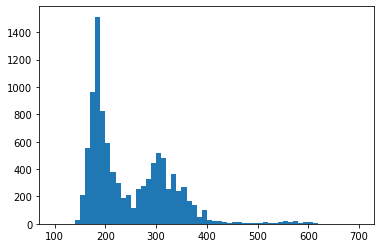

In [7]:
plt.hist([r["nGrover"][-1] for r in results], range=(100,700), bins=60)

In [7]:
# 次のroundに行く場合はNaNとする
nGrovers = np.arange(150, 601, 10)
numAng = 40
angleFracs = np.arange(1 / numAng / 2, 1, 1 / numAng)
resDf = pd.DataFrame(columns=["nGrover","r","AngleFrac","Bias","NumSamp","NumEnd"])

for nGrover in nGrovers:

    r = int((2 * nGrover + 1) * thetaTrue / np.pi)

    for angleFrac in angleFracs:
        print(nGrover, angleFrac, datetime.datetime.now())
        thetaTemp = (r + angleFrac) * np.pi / (2 * nGrover + 1)
        p = np.sin(thetaTemp) ** 2
        errs = []
        for i in range(nEstim):
            result = IQAEBinom_OnlyFinalRound_EndCIReachTol(p, nGrover, epsilon, alpha, nShotUnit, minRatio=2)
            if result is None:
                errs.append(np.nan)
            else:
                pEst = result["Estimate"]
                errs.append(pEst - p)
                # if np.sum(np.logical_not(np.isnan(errThetas))) >= nSamp:
                #     break
        errMean = np.nanmean(errs)
        numSamp = len(errs)
        numEnd = numSamp - np.sum(np.isnan(errs))
        resDf = resDf.append(pd.Series([nGrover,r,angleFrac,errMean,numSamp,numEnd], index=resDf.columns), ignore_index=True)
        resDf.to_csv("C:/Users/koich/Desktop/Code/QAEErrorVsNShotNGrover/output/Bias_VariousNGrovAngleFrac_p0.2_nG150-600.csv", index=False)

150 0.0125 2023-09-14 18:28:28.678097


<ipython-input-7-0d70868b2d55>:25: RuntimeWarning: Mean of empty slice
  errMean = np.nanmean(errs)


150 0.037500000000000006 2023-09-14 18:28:33.001278
150 0.06250000000000001 2023-09-14 18:28:37.174459
150 0.08750000000000001 2023-09-14 18:28:41.769575
150 0.11250000000000002 2023-09-14 18:28:47.184299
150 0.13750000000000004 2023-09-14 18:28:56.986552
150 0.16250000000000003 2023-09-14 18:29:05.583967
150 0.18750000000000006 2023-09-14 18:29:14.204715
150 0.21250000000000005 2023-09-14 18:29:22.153331
150 0.23750000000000004 2023-09-14 18:29:29.033204
150 0.26250000000000007 2023-09-14 18:29:35.215015
150 0.2875000000000001 2023-09-14 18:29:41.444388
150 0.31250000000000006 2023-09-14 18:29:48.253658
150 0.3375000000000001 2023-09-14 18:29:56.265751
150 0.3625000000000001 2023-09-14 18:30:05.032412
150 0.38750000000000007 2023-09-14 18:30:13.164336
150 0.4125000000000001 2023-09-14 18:30:19.670777
150 0.4375000000000001 2023-09-14 18:30:25.043974
150 0.4625000000000001 2023-09-14 18:30:29.719201
150 0.4875000000000001 2023-09-14 18:30:34.000248
150 0.5125000000000001 2023-09-14 18:

In [4]:
resDf = pd.read_csv("C:/Users/koich/Desktop/Code/QAEErrorVsNShotNGrover/output/20230914_Bias_VariousNGrovAngleFrac/Bias_VariousNGrovAngleFrac_p0.2.csv")

In [8]:
resDf

,nGrover,r,AngleFrac,Bias,NumSamp,NumEnd
0,150.0,44.0,0.0125,NaN,10000.0,0.0
1,150.0,44.0,0.0375,0.000644,10000.0,16.0
2,150.0,44.0,0.0625,0.000436,10000.0,275.0
3,150.0,44.0,0.0875,0.000229,10000.0,941.0
4,150.0,44.0,0.1125,0.000021,10000.0,1322.0
...,...,...,...,...,...,...
1835,600.0,177.0,0.8875,0.000114,10000.0,10000.0
1836,600.0,177.0,0.9125,0.000102,10000.0,10000.0
1837,600.0,177.0,0.9375,0.000091,10000.0,10000.0
1838,600.0,177.0,0.9625,0.000064,10000.0,10000.0


In [9]:
resDf["Bias"]

0            NaN
1       0.000644
2       0.000436
3       0.000229
4       0.000021
          ...   
1835    0.000114
1836    0.000102
1837    0.000091
1838    0.000064
1839    0.000025
Name: Bias, Length: 1840, dtype: float64

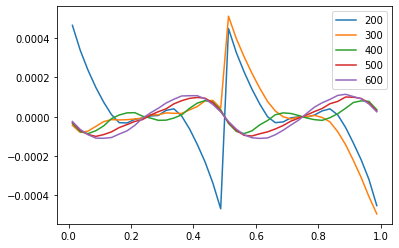

In [10]:
ax = plt.gca()
for nG in [200, 300, 400, 500, 600]:
    resDfPart = resDf[resDf["nGrover"] == nG]
    plt.plot(resDfPart["AngleFrac"], resDfPart["Bias"], label=str(nG))
plt.legend()
plt.show()

In [9]:
nGroversExp = np.array([r["nGrover"][-1] for r in results])
angleFracExp = np.modf((2 * nGroversExp + 1) * thetaTrue / np.pi)[0]

In [10]:
np.unique(nGroversExp, return_counts=True)

(array([146, 148, 150, 151, 153, 154, 156, 158, 159, 160, 161, 163, 165,
        166, 168, 170, 171, 172, 173, 175, 176, 177, 178, 180, 181, 182,
        183, 185, 186, 187, 188, 189, 190, 192, 193, 194, 195, 197, 198,
        199, 200, 202, 203, 204, 205, 207, 209, 210, 211, 212, 214, 215,
        216, 217, 219, 220, 221, 222, 224, 225, 226, 227, 228, 229, 231,
        232, 233, 234, 236, 237, 238, 239, 241, 242, 243, 244, 246, 248,
        249, 251, 253, 254, 256, 258, 259, 260, 261, 263, 265, 266, 268,
        270, 271, 272, 273, 275, 276, 277, 278, 280, 281, 282, 283, 285,
        286, 287, 288, 290, 292, 293, 295, 296, 297, 298, 299, 300, 301,
        302, 303, 304, 305, 306, 307, 308, 309, 310, 311, 312, 313, 314,
        315, 316, 317, 319, 320, 321, 322, 324, 325, 326, 327, 328, 329,
        330, 331, 332, 333, 334, 336, 337, 338, 339, 341, 342, 343, 344,
        346, 347, 348, 349, 350, 351, 352, 353, 354, 356, 357, 358, 359,
        360, 361, 362, 363, 364, 365, 366, 368, 370

In [13]:
# End num 少なすぎるところはNaNに
resDf_RemoveSmallNum = resDf.copy()
resDf_RemoveSmallNum["Bias"] = np.where(resDf_RemoveSmallNum["NumEnd"] < 1000, np.nan, resDf_RemoveSmallNum["Bias"])
biasMat = np.reshape(np.array(resDf_RemoveSmallNum["Bias"]), (len(nGrovers), len(angleFracs))).T

In [14]:
# matrixを補間
nGsInterp = np.arange(150, 601)

biasMatInterp = np.zeros((len(angleFracs), len(nGsInterp)))

for ingInterp in range(len(nGsInterp)):
    nGInterp = nGsInterp[ingInterp]
    ingOrg = np.abs(nGrovers - nGInterp).argmin()
    biasMatInterp[:,ingInterp] = biasMat[:,ingOrg]

In [15]:
from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import MaxNLocator

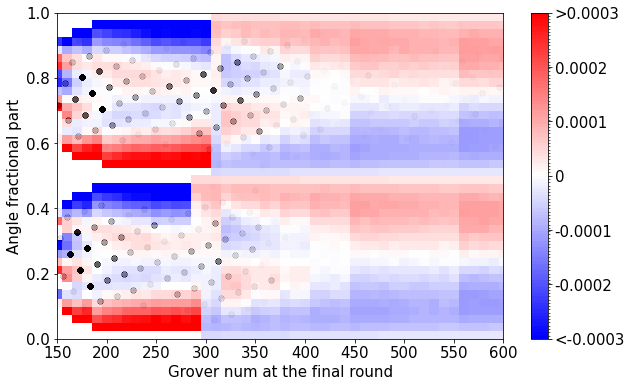

In [16]:
fig, ax = plt.subplots(figsize=(10,6))
levels = MaxNLocator(nbins=100).tick_values(-0.0003, 0.0003)
cmap = plt.colormaps['bwr']
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)
heatmap = ax.pcolor(nGsInterp, angleFracs, biasMatInterp, cmap="bwr", norm=norm)
cbar = fig.colorbar(heatmap, ax=ax) # カラーバー

ticks  = np.arange(-0.0003, 0.00031, 0.0001)
labels = ['<-0.0003', '-0.0002', '-0.0001', '0', '0.0001', '0.0002', '>0.0003']
cbar.set_ticks(ticks)
cbar.set_ticklabels(labels)
cbar.ax.tick_params(axis='y', labelsize=15)

ax.scatter(nGroversExp,angleFracExp, c="k", alpha=0.005)
ax.set_ylim(0,1)
ax.set_xlim(150,600)
ax.set_xlabel("Grover num at the final round", fontsize=15)
ax.set_ylabel("Angle fractional part", fontsize=15)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)

plt.savefig("C:/Users/koich/Desktop/Code/QAEErrorVsNShotNGrover/output/20230914_Bias_VariousNGrovAngleFrac/BiasHeatmap&NGrovFracAngleScatter_p0.2.png")
plt.show()

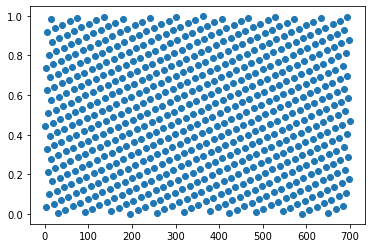

In [22]:
ax = plt.gca()
plt.scatter(np.arange(1, 700), np.modf((2 * np.arange(1, 700) + 1) * np.arcsin(np.sqrt(0.2)) / np.pi)[0])
plt.show()